<a href="https://colab.research.google.com/github/ArturRSO15/lab-work/blob/main/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
with open("students.txt", "w", encoding="utf-8") as file:
    file.write("Иван;A1;5,4,5\n")
    file.write("Анна;A1;4,4,5\n")
    file.write("Магомед;B2;3,4,4\n")
    file.write("Марина;B2;5,5,5\n")
    file.write("Олег;A1;4,5,5\n")
    file.write("Сергей;B2;5,4,4\n")
    file.write("Елена;C3;3,4,5\n")
    file.write("Расул;C3;5,5,4\n")
    file.write("Ольга;A1;4,4,4\n")
    file.write("Никита;B2;5,5,5\n")
    file.write("Ирина;C3;4,5,5\n")
    file.write("Алексей;A1;3,4,3\n")
    file.write("Татьяна;B2;4,5,4\n")
    file.write("Виктор;C3;5,5,5\n")
    file.write("Наталья;A1;5,4,4\n")

print("Файл students.txt создан и заполнен студентами")

Файл students.txt создан и заполнен студентами


In [ ]:
class Student: # позволяет создать класс студент и харанить его характеристики и управлять ими
    def __init__(self, name, group, grades): # это конструктор данных который вызыввается автоматически когда создается объяект
                          # self это ссылка на сам объект это нужно чтобы сохронять данные внутри каждого объекта
        self.name = name  # здесь берется значение name и сохроняется внутри объекта
        self.group = group # берется значение group и сохроняется внутри объекта
        self.grades = grades # берется значение grades и сохроняется внутри объекта

    def average_grade(self): #это функция внури класса и считает средний балл студента
        return sum(self.grades) / len(self.grades) # суммирует все оценки студента и делится на кол-во оценок

    def is_excellent(self):
        return self.average_grade() >= 4.5 #проверяет является ли студент отличником


students = []  # мы создаем пустой список, он будет хранить все объекты студентов

# Чтение файла
with open("students.txt", "r", encoding="utf-8") as file: # здесь происхоидть открытие файла
    for line in file: # читает файл от первой до последей линий  цикл читает каждую строчку файла
        name, group, grades_str = line.strip().split(";")# line.strip()-удадяет лишние символы, split(";")-ставит между ними данный знак
        grades = list(map(int, grades_str.split(","))) # это строка разделяет оценки ',' и привращает их в числа
        student = Student(name, group, grades) # мы создаем объект класса студент
        students.append(student)    # метод append добовляет элемент в список
# Запись отличников
with open("excellent_students.txt", "w", encoding="utf-8") as file: # создается новый файл
    for student in students:  # здесь запускается цикл котрый проходится по каждому студенту
        if student.is_excellent(): # здесь вызывается метод который считает средний балл каждого студента
            file.write(f"{student.name} - {student.group}\n")# добовляем студента в список если он отличник

# Средний балл по группам
groups = {} # создаем пустой словарь

for student in students: # цикл проходит по каждому студенту
    if student.group not in groups: #здесь программа проверяет если такая строчка в словаре
        groups[student.group] = [] #создаем новый ключ в словаре
    groups[student.group].append(student.average_grade())#

print("Средний балл по группам:")
for group, averages in groups.items():
    group_avg = sum(averages) / len(averages)
    print(f"Группа {group}: {group_avg:.2f}")

Средний балл по группам:
Группа A1: 4.22
Группа B2: 4.47
Группа C3: 4.58


In [ ]:
import re # импортируем модуль re. Это стандартный моддуль питона для работы с регулярными выражениями   Регулярные выражения- это шаблон для поиска текста

log_text = """
2025-03-07 10:15:32 INFO Server started at 192.168.1.10
2025-03-07 10:16:01 ERROR Connection failed from 10.0.0.5
2025-03-07 10:17:45 WARNING USER LOGIN FAILED
Admin email: admin@example.com
Support email: support@mail.com
"""# мы создаем многосторочнуй строку log_text в которой пишем лог сервера в нем есть: временные метки,ip адреса,сообщения и email

# 1. Найти IPv4 адреса
ip_pattern = r'\b(?:\d{1,3}\.){3}\d{1,3}\b' #здесь создается регулярное выражение которое ищет ipv4 адреса
ips = re.findall(ip_pattern, log_text)# здесь берется наше выражение и ищем все совпадения с помощью findaal() в log_text

# 2. Найти временные метки
time_pattern = r'\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}'# здесь создается шаблон регулярного выражения, который ищет дату и время
timestamps = re.findall(time_pattern, log_text) # ищет все совпадения шаблона в тексте

# 3. Найти слова в UPPERCASE
upper_pattern = r'\b[A-Z]{2,}\b'# этот шаблон ищет все слова написанные с заглавной буквы
upper_words = re.findall(upper_pattern, log_text)

# 4. Заменить email
email_pattern = r'\b[\w\.-]+@[\w\.-]+\.\w+\b' # ищет email адреса
log_without_emails = re.sub(email_pattern, "[EMAIL PROTECTED]", log_text)

print("IPv4 адреса:", ips)
print("Временные метки:", timestamps)
print("UPPERCASE слова:", upper_words)

print("\nЛог без email:")
print(log_without_emails)

IPv4 адреса: ['192.168.1.10', '10.0.0.5']
Временные метки: ['2025-03-07 10:15:32', '2025-03-07 10:16:01', '2025-03-07 10:17:45']
UPPERCASE слова: ['INFO', 'ERROR', 'WARNING', 'USER', 'LOGIN', 'FAILED']

Лог без email:

2025-03-07 10:15:32 INFO Server started at 192.168.1.10
2025-03-07 10:16:01 ERROR Connection failed from 10.0.0.5
2025-03-07 10:17:45 WARNING USER LOGIN FAILED
Admin email: [EMAIL PROTECTED]
Support email: [EMAIL PROTECTED]



Исходные данные:
     Товар    Цена  Количество
0  Ноутбук  1000.0           5
1  Телефон   500.0          10
2  Планшет     NaN           2
3  Ноутбук  1200.0        2000
4  Телефон   450.0           3
5  Планшет   300.0           0
6  Ноутбук     NaN           7
Обработанные данные
     Товар    Цена  Количество  Общая_стоимость
0  Ноутбук  1000.0           5           5000.0
1  Телефон   500.0          10           5000.0
2  Планшет   500.0           2           1000.0
4  Телефон   450.0           3           1350.0
6  Ноутбук   500.0           7           3500.0

Выручка по товарам:
Товар
Ноутбук    8500.0
Планшет    1000.0
Телефон    6350.0
Name: Общая_стоимость, dtype: float64


/tmp/ipykernel_1127/4085959259.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Цена'].fillna(median_price, inplace=True)#заполняем столбец пропусками


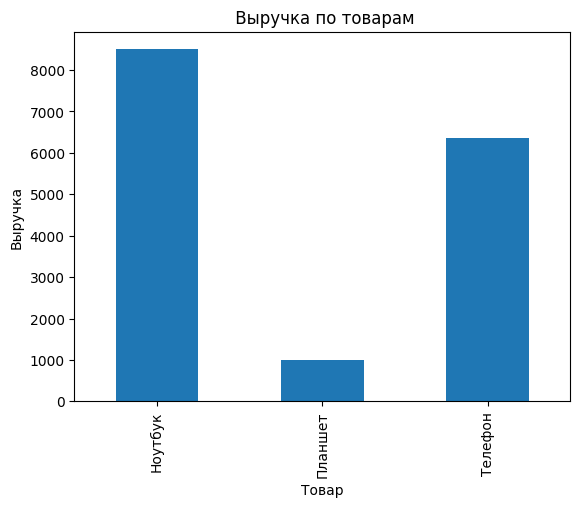

In [9]:
import pandas as pd#импортируем библиотку pandas для работы с таблицами и анализа данных
import numpy as np# импортируем бибилиотку nampy для математических операций и представления NaN
import matplotlib.pyplot as plt #это библиотека нам нужна для построения графика

# 1. Создание DataFrame
data = {
    'Товар': ['Ноутбук', 'Телефон', 'Планшет', 'Ноутбук', 'Телефон', 'Планшет', 'Ноутбук'],
    'Цена': [1000, 500, np.nan, 1200, 450, 300, np.nan],
    'Количество': [5, 10, 2, 2000, 3, 0, 7]        # здесь мы создаем нашу таблицу
}

df = pd.DataFrame(data)#здесь создаетсчя datafarme (таблица в pandas)

print("Исходные данные:")
print(df) #выводим нашу первоначальную таблицу

# 2. Заполнение пропусков медианой
median_price = df['Цена'].median()#находим среднюю цену
df['Цена'].fillna(median_price, inplace=True)#заполняем столбец пропусками


# 3. Удаление выбросов
df = df[(df['Количество'] >= 1) & (df['Количество'] <= 1000)]# это строка фильтрует строки dateframe и удаляет неправильные значения

# 4. Новый столбец
df['Общая_стоимость'] = df['Цена'] * df['Количество'] #создает новый столбец "общая стоимость"
print("Обработанные данные")
print(df)

# 5. Группировка
revenue = df.groupby('Товар')['Общая_стоимость'].sum() #здесь выполняется группировка данных (grophu()используется для объединения строк по одинаковым значениям)

print("\nВыручка по товарам:")
print(revenue)#выводим выручку по товаром

# 6. Построение графика
revenue.plot(kind='bar') #строим столбачатую диаграмму

plt.title(" Выручка по товарам")#добовляет название товара
plt.xlabel("Товар")#ось x это товар
plt.ylabel("Выручка") # ось y это выручка
plt.show() # выводит диаграмму

In [10]:
import numpy as np #импортируем библиотеку numpy для работы с массивами и математическами операциями

A = np.random.randint(1, 11, (5, 5))
B = np.random.randint(1, 11, (5, 5))       # генерируем случайные матрицы

print("Матрица A:")
print(A)

print("\nМатрица B:")
print(B)

# Поэлементное произведение
elementwise = A * B
print("\nПоэлементное произведение:")
print(elementwise)# ищем поэлементное произведение и выводим

#  Матричное произведение
matrix_product = np.dot(A, B)#находим матричное произведение с помощью np.dot()
print("\nМатричное произведение:")
print(matrix_product)

#  Определитель матрицы A
det_A = np.linalg.det(A) #находим определитель матрицы
print("\nОпределитель матрицы A:")
print(det_A)

#  Транспонированная матрица B
B_transpose = B.T
print("\nТранспонированная матрица B:")
print(B_transpose)

#  Обратная матрица A
if det_A != 0:  #проверяем определитель
    A_inv = np.linalg.inv(A) # находим обратную матрицу
    print("\nОбратная матрица A:")
    print(A_inv)
else:
    print("\nОбратную матрицу найти нельзя (det(A) = 0)")

#  Вектор C (сумма строк A)
C = A.sum(axis=1) #создаем вектор c
print("\nВектор C (сумма строк A):")
print(C)

# Решение системы A * x = C
try:
    x = np.linalg.solve(A, C) # находим вектор x
    print("\nРешение системы A * x = C:")
    print(x)
except:
    print("\nСистему решить невозможно")

Матрица A:
[[10  3  3  2  1]
 [ 5  3  2  4  1]
 [ 9  4  3  4  1]
 [ 2  9  6  2  8]
 [10  1  8  2  1]]

Матрица B:
[[ 6  6  2  7  3]
 [ 3  7  9  9  7]
 [10  4  6  8  9]
 [ 1  8  4  2  4]
 [ 6  6  9  1  4]]

Поэлементное произведение:
[[60 18  6 14  3]
 [15 21 18 36  7]
 [90 16 18 32  9]
 [ 2 72 24  4 32]
 [60  6 72  2  4]]

Матричное произведение:
[[107 115  82 126  90]
 [ 69  97  74  87  74]
 [106 132  97 132 102]
 [149 163 201 155 163]
 [151 121  94 148 121]]

Определитель матрицы A:
-581.9999999999997

Транспонированная матрица B:
[[ 6  6  2  7  3]
 [ 3  7  9  9  7]
 [10  4  6  8  9]
 [ 1  8  4  2  4]
 [ 6  6  9  1  4]]

Обратная матрица A:
[[ 0.395189    0.26116838 -0.42955326 -0.02405498 -0.03436426]
 [-0.9862543  -1.4604811   1.94158076  0.06872852 -0.04467354]
 [-0.59450172 -0.58419244  0.7766323   0.02749141  0.18213058]
 [ 0.19072165  0.86082474 -0.68556701 -0.04639175  0.00515464]
 [ 1.40893471  1.80068729 -2.48797251  0.04467354 -0.0790378 ]]

Вектор C (сумма строк A):
[19 15

In [12]:
import math # импортируем модуль math которая содержит математические функций

def safe_apply(func, data):#создается функция которая принимает два аргумента (func,data)
    results = []
    errors = []

    for element in data: # создаем цикл for где перербираем все элементы в date
        try:
            result = func(element)#вычисляем func  для каждого элемента
            results.append(result)# результат добавляем в список results
        except Exception as e:# если возникла ошибка то мы запоминаем ее как "e"
            errors.append((element, type(e).__name__)) #добавляем в наш список errors элемент и тип ошибки

    return results, errors


data = ['4', '16', 'text', '-25', '9.0','5','-23','abc','55','2**2','1','',]

# лямбда-функция для квадратного корня
sqrt_func = lambda x: math.sqrt(float(x))

results, errors = safe_apply(sqrt_func, data)

print("Успешные результаты:")
print(results)

print("\nОшибки:")
print(errors)

Успешные результаты:
[2.0, 4.0, 3.0, 2.23606797749979, 7.416198487095663, 1.0]

Ошибки:
[('text', 'ValueError'), ('-25', 'ValueError'), ('-23', 'ValueError'), ('abc', 'ValueError'), ('2**2', 'ValueError'), ('', 'ValueError')]


In [14]:
import time # импортируем модуль time который позволяет работать со временим
import numpy as np # импортируем библиотеку numpy она позволяет работать с массивами или


class Timer: # создаем класс timer он реалезует контекстный менеджер

    def __enter__(self): # магический метод enter он автоматически вызывается когда программа входит в блок
        self.start = time.time()#выполняется отчет времени


    def __exit__(self, exc_type, exc_value, traceback):
        end = time.time()#счтает время окончания функций
        elapsed = end - self.start#из времени окончания  функция вычитается начло
        print(f"Время выполнения: {elapsed:.4f} секунд")#


# использование Timer для задачи с матрицами
with Timer():

    A = np.random.randint(1, 11, (5, 5))
    B = np.random.randint(1, 11, (5, 5))

    elementwise = A * B
    matrix_product = np.dot(A, B)

    det_A = np.linalg.det(A)
    B_transpose = B.T

    if det_A != 0:
        A_inv = np.linalg.inv(A)

    C = A.sum(axis=1)

    x = np.linalg.solve(A, C)

Время выполнения: 0.0004 секунд


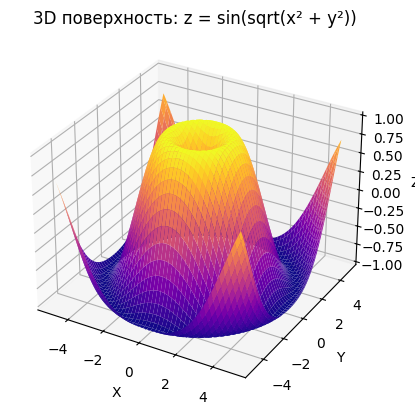

In [15]:
import numpy as np # библиотека для работы с массивами
import matplotlib.pyplot as plt # для построения диграммы

from mpl_toolkits.mplot3d import Axes3D # модуль для посторения 3d диаграммы

# Создание сетки значений
x = np.linspace(-5, 5, 100) # создает массив чисел от и до
y = np.linspace(-5, 5, 100)

X, Y = np.meshgrid(x, y) #функция meshgrid создает координатную сетку

#  Вычисление функции
Z = np.sin(np.sqrt(X**2 + Y**2))

#  Создание 3D графика
fig = plt.figure() # создание объекта фигуры
ax = fig.add_subplot(111, projection='3d')# чтобы она была 3 d

# Построение поверхности
ax.plot_surface(X, Y, Z, cmap='plasma')#Функция plot_surface() строит 3D поверхность.



#  Подписи осей
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title("3D поверхность: z = sin(sqrt(x² + y²))")

plt.show()